**Course:** DA5400W — Data Analytics Lab  
**Instructor:** Dr. Arun B Ayyar, IIT Madras  
**Student Name:** Amardeep Kumar

**Roll Number:** DA25M502

# Assignment 2: Classification and Regression

**Total Marks:** 10  
**Level:** Intermediate  
**Topics:** Training, hyperparameter tuning, and evaluation of classification and regression algorithms

---

## Instructions

This assignment contains two parts:
1. **Part A: Classification on Unbalanced Data (5 marks)**
2. **Part B: Regression Models (5 marks)**

**Important:**
- Datasets are pre-generated and provided for you
- Store results in the **exact variable names** specified in each task
- Execute all cells before submission
- Otter-Grader will automatically test your outputs

---

## Setup: Imports and Dataset Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


---

# PART A: CLASSIFICATION ON UNBALANCED DATA (5 Marks)

---

## Classification - Data Preparation (PROVIDED)

In [2]:
# Generate unbalanced classification dataset (90-10 class imbalance)
X_class, y_class = make_classification(n_samples=1000, n_features=20, n_informative=15,
                                       n_redundant=5, weights=[0.9, 0.1], random_state=42)

# Split data with stratification 80:20
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_class,y_class,test_size=0.2,random_state=42)

# Standardize features
scaler_class = StandardScaler()
X_class_train_scaled = scaler_class.fit_transform(X_class_train)
X_class_test_scaled = scaler_class.transform(X_class_test)

print("Classification Dataset:")
print(f"Training samples: {X_class_train_scaled.shape[0]}, Testing samples: {X_class_test_scaled.shape[0]}")
print(f"Features: {X_class_train_scaled.shape[1]}")
print(f"Class distribution (train): {np.bincount(y_class_train)}")
print(f"Class imbalance ratio: {np.bincount(y_class)[0] / np.bincount(y_class)[1]:.2f}:1")

Classification Dataset:
Training samples: 800, Testing samples: 200
Features: 20
Class distribution (train): [716  84]
Class imbalance ratio: 8.80:1


## Classification - Task 1: Baseline Models (1.5 Marks)

Train 5 classification models with default hyperparameters:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Support Vector Machine (SVM)
5. Gaussian Naive Bayes

**Expected Output Variable: `classification_baseline_results`**
- Create a pandas DataFrame with:
  - Index: Model names
  - Columns: "Accuracy", "ROC-AUC"
  - Values: Metrics calculated on test set

In [3]:
# BEGIN QUESTION
# name: classification_baseline_models
# points: 1.5

# Train 5 baseline classification models
# Store results in DataFrame: classification_baseline_results
# Columns: "Accuracy", "ROC-AUC"
# Index: Model names

result = {}
# Logistic Regression
logistic_model = LogisticRegression()
logistic_model.fit(X_class_train_scaled,y_class_train)
y_pred_logistic = logistic_model.predict(X_class_test_scaled)
y_porba_logistic = logistic_model.predict_proba(X_class_test_scaled)[:, 1]
result['Logistic Regression'] = [accuracy_score(y_class_test,y_pred_logistic),roc_auc_score(y_class_test,y_porba_logistic)]

# Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(X_class_train_scaled,y_class_train)
y_pred_descision = decision_tree_model.predict(X_class_test_scaled)
y_proba_decision = decision_tree_model.predict_proba(X_class_test_scaled)[:, 1]
result['Decision Tree Classifier'] = [accuracy_score(y_class_test,y_pred_descision),roc_auc_score(y_class_test,y_proba_decision)]

# Random Forest Classifier
random_forest_model = RandomForestClassifier()
random_forest_model.fit(X_class_train_scaled,y_class_train)
y_pred_random_forest = random_forest_model.predict(X_class_test_scaled)
y_proba_random_forest = random_forest_model.predict_proba(X_class_test_scaled)[:, 1]
result['Random Forest Classifier'] = [accuracy_score(y_class_test,y_pred_random_forest),roc_auc_score(y_class_test,y_proba_random_forest)]

# Support Vector Machine (SVM)
svc_model = SVC(probability = True)
svc_model.fit(X_class_train_scaled,y_class_train)
y_pred_svc = svc_model.predict(X_class_test_scaled)
y_proba_svc = svc_model.predict_proba(X_class_test_scaled)[:, 1]
result['Support Vector Machine'] = [accuracy_score(y_class_test,y_pred_svc),roc_auc_score(y_class_test,y_proba_svc)]

# Gaussian Naive Bayes
gaussian_model = GaussianNB()
gaussian_model.fit(X_class_train_scaled,y_class_train)
y_pred_gaussian = gaussian_model.predict(X_class_test_scaled)
y_proba_gaussian = gaussian_model.predict_proba(X_class_test_scaled)[:, 1]
result['Gaussian Naive Bayes'] = [accuracy_score(y_class_test,y_pred_gaussian),roc_auc_score(y_class_test,y_proba_gaussian)]


classification_baseline_results = pd.DataFrame(result,index=['Accuracy','ROC-AUC']).T # Replace with your DataFrame

print("Classification Baseline Model Performance:")
print(classification_baseline_results)

# END QUESTION

Classification Baseline Model Performance:
                          Accuracy   ROC-AUC
Logistic Regression          0.935  0.884005
Decision Tree Classifier     0.920  0.705739
Random Forest Classifier     0.930  0.876374
Support Vector Machine       0.960  0.984127
Gaussian Naive Bayes         0.910  0.876984


In [4]:
# BEGIN TESTS
assert classification_baseline_results is not None, "classification_baseline_results not created"
assert isinstance(classification_baseline_results, pd.DataFrame), "Must be a DataFrame"
assert classification_baseline_results.shape[0] == 5, "Must have 5 models"
assert classification_baseline_results.shape[1] == 2, "Must have 2 columns"
assert "Accuracy" in classification_baseline_results.columns
assert "ROC-AUC" in classification_baseline_results.columns
# assert all(0 <= classification_baseline_results["Accuracy"] <= 1)
# assert all(0 <= classification_baseline_results["ROC-AUC"] <= 1)
assert ((classification_baseline_results["Accuracy"] >= 0) &
        (classification_baseline_results["Accuracy"] <= 1)).all()

assert ((classification_baseline_results["ROC-AUC"] >= 0) &
        (classification_baseline_results["ROC-AUC"] <= 1)).all()
# END TESTS

## Classification - Task 2: Hyperparameter Tuning (2.5 Marks)

Use GridSearchCV to tune hyperparameters for all 5 classification algorithms.

**Hyperparameter Grids:**
- **Logistic Regression:** `{'C': [0.01, 0.1, 1, 10], 'class_weight': [None, 'balanced']}`
- **Decision Tree:** `{'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10], 'class_weight': [None, 'balanced']}`
- **Random Forest:** `{'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'class_weight': [None, 'balanced']}`
- **SVM:** `{'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'class_weight': [None, 'balanced']}`
- **Naive Bayes:** `{'var_smoothing': [1e-9, 1e-8, 1e-7]}`

**Expected Output Variables:**
- `classification_tuned_models` (dict): Keys = model names, Values = best fitted models
- `classification_tuning_results` (dict): Keys = model names, Values = best hyperparameters

In [5]:
# BEGIN QUESTION
# name: classification_hyperparameter_tuning
# points: 2.5

# Tune hyperparameters for all 5 classification algorithms
# Use GridSearchCV with cv=5, scoring='roc_auc'
# Store tuned models in: classification_tuned_models
# Store best params in: classification_tuning_results

classification_tuned_models = {}  # Dict with tuned models
classification_tuning_results = {}  # Dict with best parameters

# Tune Logistic Regression
# Your code here
logistic_model = LogisticRegression()
logi_param_grid = {'C': [0.01, 0.1, 1, 10], 'class_weight': [None, 'balanced']}
logi_grid = GridSearchCV(estimator = logistic_model , param_grid = logi_param_grid , cv=5, scoring='roc_auc' , n_jobs = -1 )
logi_grid.fit(X_class_train_scaled,y_class_train)
classification_tuned_models['Logistic Regression'] = logi_grid.best_estimator_
classification_tuning_results['Logistic Regression'] = logi_grid.best_params_

# Tune Decision Tree Classifier
# Your code here
decision_tree_model = DecisionTreeClassifier()
deci_param_grid = {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10], 'class_weight': [None, 'balanced']}
deci_grid = GridSearchCV(estimator = decision_tree_model , param_grid = deci_param_grid , cv=5, scoring='roc_auc' , n_jobs = -1 )
deci_grid.fit(X_class_train_scaled,y_class_train)
classification_tuned_models['Decision Tree Classifier'] = deci_grid.best_estimator_
classification_tuning_results['Decision Tree Classifier'] = deci_grid.best_params_

# Tune Random Forest Classifier
# Your code here
random_forest_model = RandomForestClassifier()
forest_param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'class_weight': [None, 'balanced']}
forest_grid = GridSearchCV(estimator = random_forest_model , param_grid = forest_param_grid , cv=5, scoring='roc_auc' , n_jobs = -1 )
forest_grid.fit(X_class_train_scaled,y_class_train)
classification_tuned_models['Random Forest Classifier'] = forest_grid.best_estimator_
classification_tuning_results['Random Forest Classifier'] = forest_grid.best_params_

# Tune SVM
# Your code here
svm_model = SVC(probability=True)
svm_param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'class_weight': [None, 'balanced']}
svm_grid = GridSearchCV(estimator = svm_model , param_grid = svm_param_grid , cv=5, scoring='roc_auc' , n_jobs = -1 )
svm_grid.fit(X_class_train_scaled,y_class_train)
classification_tuned_models['Support Vector Machine'] = svm_grid.best_estimator_
classification_tuning_results['Support Vector Machine'] = svm_grid.best_params_

# Tune Gaussian Naive Bayes
# Your code here
gaussian_model = GaussianNB()
gaussian_param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7]}
gaussian_grid = GridSearchCV(estimator = gaussian_model , param_grid = gaussian_param_grid , cv=5, scoring='roc_auc' , n_jobs = -1 )
gaussian_grid.fit(X_class_train_scaled,y_class_train)
classification_tuned_models['Gaussian Naive Bayes'] = gaussian_grid.best_estimator_
classification_tuning_results['Gaussian Naive Bayes'] = gaussian_grid.best_params_

print("Best Hyperparameters Found:")
for model_name, params in classification_tuning_results.items():
    print(f"{model_name}: {params}")

# END QUESTION

Best Hyperparameters Found:
Logistic Regression: {'C': 0.1, 'class_weight': 'balanced'}
Decision Tree Classifier: {'class_weight': None, 'max_depth': 20, 'min_samples_split': 5}
Random Forest Classifier: {'class_weight': 'balanced', 'max_depth': 20, 'n_estimators': 100}
Support Vector Machine: {'C': 1, 'class_weight': None, 'kernel': 'rbf'}
Gaussian Naive Bayes: {'var_smoothing': 1e-09}


In [6]:
# help(LogisticRegression)

In [7]:
# BEGIN TESTS
assert isinstance(classification_tuned_models, dict), "Must be a dictionary"
assert isinstance(classification_tuning_results, dict), "Must be a dictionary"
assert len(classification_tuned_models) == 5, "Must have 5 models"
assert len(classification_tuning_results) == 5, "Must have 5 entries"
# END TESTS

## Classification - Task 3: Evaluation & Comparison (1.0 Mark)

Evaluate all tuned models and create visualizations.

**Expected Output Variables:**
- `classification_final_results` (DataFrame): Model names × ["Accuracy", "ROC-AUC"], sorted by ROC-AUC
- `classification_roc_plot` (figure): ROC curves for all 5 models

In [8]:
# BEGIN QUESTION
# name: classification_evaluation_table
# points: 0.5

# Evaluate all tuned models on test set
# Create DataFrame: classification_final_results
# Sort by ROC-AUC in descending order

result = {}
#Logistic Regression
best_logistic_model = logi_grid.best_estimator_
y_pred_logistic = best_logistic_model.predict(X_class_test_scaled)
y_porba_logistic = best_logistic_model.predict_proba(X_class_test_scaled)[:, 1]
result['Logistic Regression'] = [accuracy_score(y_class_test,y_pred_logistic),roc_auc_score(y_class_test,y_porba_logistic)]

#Decision tree model
best_decision_tree_model = deci_grid.best_estimator_
y_pred_descision = best_decision_tree_model.predict(X_class_test_scaled)
y_proba_decision = best_decision_tree_model.predict_proba(X_class_test_scaled)[:, 1]
result['Decision Tree Classifier'] = [accuracy_score(y_class_test,y_pred_descision),roc_auc_score(y_class_test,y_proba_decision)]

#Random Forest Model
best_forest_model = forest_grid.best_estimator_
y_pred_random_forest = best_forest_model.predict(X_class_test_scaled)
y_proba_random_forest = best_forest_model.predict_proba(X_class_test_scaled)[:, 1]
result['Random Forest Classifier'] = [accuracy_score(y_class_test,y_pred_random_forest),roc_auc_score(y_class_test,y_proba_random_forest)]

#Support Vector Machine
best_svm_model = svm_grid.best_estimator_
y_pred_svm = best_svm_model.predict(X_class_test_scaled)
y_proba_svc = best_svm_model.predict_proba(X_class_test_scaled)[:, 1]
result['Support Vector Machine'] = [accuracy_score(y_class_test,y_pred_svc),roc_auc_score(y_class_test,y_proba_svc)]

#Gaussian Model
btest_gaussian_model = gaussian_grid.best_estimator_
y_pred_gaussian = btest_gaussian_model.predict(X_class_test_scaled)
y_proba_gaussian = btest_gaussian_model.predict_proba(X_class_test_scaled)[:, 1]
result['Gaussian Naive Bayes'] = [accuracy_score(y_class_test,y_pred_gaussian),roc_auc_score(y_class_test,y_proba_gaussian)]

classification_final_results = pd.DataFrame(result,index=["Accuracy", "ROC-AUC"]).T.sort_values(by = 'ROC-AUC' , ascending = False)  # Replace with your DataFrame

print("Classification Final Model Performance:")
print(classification_final_results)
print(f"\nBest Model: {classification_final_results.index[0]} with ROC-AUC = {classification_final_results.iloc[0]['ROC-AUC']:.4f}")

# END QUESTION

Classification Final Model Performance:
                          Accuracy   ROC-AUC
Support Vector Machine       0.960  0.984127
Random Forest Classifier     0.935  0.974512
Logistic Regression          0.835  0.893162
Gaussian Naive Bayes         0.910  0.876984
Decision Tree Classifier     0.915  0.677045

Best Model: Support Vector Machine with ROC-AUC = 0.9841


In [9]:
# BEGIN TESTS
assert classification_final_results is not None
assert isinstance(classification_final_results, pd.DataFrame)
assert classification_final_results.shape[0] == 5
assert classification_final_results.shape[1] == 2
assert "Accuracy" in classification_final_results.columns
assert "ROC-AUC" in classification_final_results.columns
# END TESTS

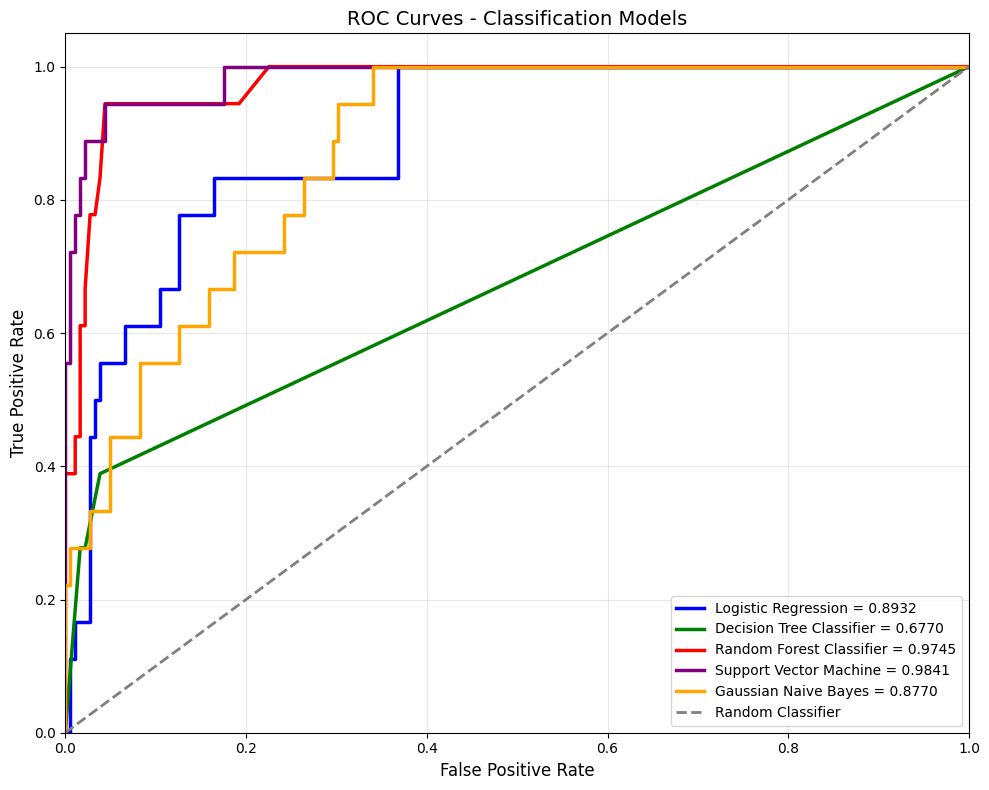

In [10]:
# BEGIN QUESTION
# name: classification_roc_curves
# points: 0.5

# Plot ROC curves for all 5 tuned models
# Store figure in: classification_roc_plot

classification_roc_plot = plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Your code here to plot ROC curves
# For each model:
#   - Get probability predictions
#   - Calculate FPR, TPR using roc_curve()
#   - Calculate AUC and plot

for (name, model),color  in zip(classification_tuned_models.items(),colors):
    y_proba_logit = model.predict_proba(X_class_test_scaled)[:, 1]
    auc  = roc_auc_score(y_class_test, y_proba_logit)
    fpr, tpr, _ = roc_curve(y_class_test, y_proba_logit)
    plt.plot(fpr, tpr, lw=2.5,color=color, label=f'{name} = {auc:.4f}')


# Plot random classifier baseline
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Classification Models', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# END QUESTION

In [11]:
# BEGIN TESTS
assert classification_roc_plot is not None
# END TESTS

---

# PART B: REGRESSION MODELS (5 Marks)

---

## Regression - Data Preparation (PROVIDED)

In [12]:
# Generate regression dataset
X_reg, y_reg = make_regression(n_samples=500, n_features=10, n_informative=8,
                               noise=20, random_state=42)

# Split data
X_reg_train, X_reg_test, y_reg_train, y_reg_test =train_test_split(X_reg,y_reg,test_size=0.2,random_state=42)

# Standardize features
scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

print("Regression Dataset:")
print(f"Training samples: {X_reg_train_scaled.shape[0]}, Testing samples: {X_reg_test_scaled.shape[0]}")
print(f"Features: {X_reg_train_scaled.shape[1]}")
print(f"Target range: [{y_reg.min():.2f}, {y_reg.max():.2f}]")

Regression Dataset:
Training samples: 400, Testing samples: 100
Features: 10
Target range: [-405.84, 478.39]


## Regression - Task 1: Baseline Models (1.5 Marks)

Train 5 regression models with default hyperparameters:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Polynomial Regression (degree=2)
5. Logarithmic Regression

**Expected Output Variable: `regression_baseline_results`**
- Create a pandas DataFrame with:
  - Index: Model names
  - Columns: "MSE", "R² Score"
  - Values: Metrics calculated on test set

In [13]:
# BEGIN QUESTION
# name: regression_baseline_models
# points: 1.5

# Train 5 baseline regression models
# Store results in DataFrame: regression_baseline_results
# Columns: "MSE", "R² Score"
# Index: Model names

# Hints:
# - Linear Regression: LinearRegression()
# - Ridge: Ridge()
# - Lasso: Lasso()
# - Polynomial: Use PolynomialFeatures(degree=2) then LinearRegression()
# - Logarithmic: Use np.log1p() transformation on features
# - Metrics: mean_squared_error(), r2_score()

results = {}
# Linear Regression: LinearRegression()
linear_model = LinearRegression()
linear_model.fit(X_reg_train_scaled,y_reg_train)
y_pred_lr = linear_model.predict(X_reg_test_scaled)
results["Linear Regression"] = [mean_squared_error(y_reg_test, y_pred_lr), r2_score(y_reg_test, y_pred_lr)]

# Ridge: Ridge()
ridge_model = Ridge()
ridge_model.fit(X_reg_train_scaled,y_reg_train)
y_pred_ridge = ridge_model.predict(X_reg_test_scaled)
results["Ridge"] = [mean_squared_error(y_reg_test,y_pred_ridge),r2_score(y_reg_test, y_pred_ridge)]

# Lasso: Lasso()
lasso_model = Lasso()
lasso_model.fit(X_reg_train_scaled,y_reg_train)
y_pred_lasso = lasso_model.predict(X_reg_test_scaled)
results["Lasso"] = [mean_squared_error(y_reg_test, y_pred_lasso), r2_score(y_reg_test, y_pred_lasso)]

# Polynomial: Use PolynomialFeatures(degree=2) then LinearRegression()
from sklearn.pipeline import Pipeline
poly_model = Pipeline([
    ('poly',PolynomialFeatures(degree=2,include_bias=True)),
    ('linear',LinearRegression())
])
poly_model.fit(X_reg_train_scaled,y_reg_train)
y_pred_poly = poly_model.predict(X_reg_test_scaled)
results["Polynomial"] = [mean_squared_error(y_reg_test,y_pred_poly),r2_score(y_reg_test,y_pred_poly)]

# Logarithmic: Use np.log1p()
X_train_shifted = X_reg_train_scaled - X_reg_train_scaled.min() + 1
X_test_shifted = X_reg_test_scaled - X_reg_test_scaled.min() + 1
log_model = LinearRegression()
log_model.fit(np.log1p(X_train_shifted),y_reg_train)
y_pred_log = log_model.predict(np.log1p(X_test_shifted))
results["Logarithmic"] = [mean_squared_error(y_reg_test,y_pred_log),r2_score(y_reg_test,y_pred_log)]

regression_baseline_results = pd.DataFrame(results,index=['MSE','R² Score']).T  # Replace with your DataFrame
# regression_baseline_results = pd.DataFrame(results.values(),columns=['MSE','R² Score'],index=results.keys())

print("Regression Baseline Model Performance:")
print(regression_baseline_results)

# END QUESTION

Regression Baseline Model Performance:
                           MSE  R² Score
Linear Regression   361.983342  0.984585
Ridge               363.040070  0.984540
Lasso               380.599390  0.983792
Polynomial          381.503228  0.983754
Logarithmic        4042.518738  0.827853


In [14]:
# BEGIN TESTS
assert regression_baseline_results is not None
assert isinstance(regression_baseline_results, pd.DataFrame)
assert regression_baseline_results.shape[0] == 5, "Must have 5 models"
assert regression_baseline_results.shape[1] == 2, "Must have 2 columns"
assert "MSE" in regression_baseline_results.columns
assert "R² Score" in regression_baseline_results.columns
# END TESTS

## Regression - Task 2: Hyperparameter Tuning (2.5 Marks)

Use GridSearchCV to tune hyperparameters for all 5 regression algorithms.

**Hyperparameter Grids:**
- **Linear Regression:** `{'fit_intercept': [True, False]}`
- **Ridge:** `{'alpha': [0.001, 0.01, 0.1, 1, 10]}`
- **Lasso:** `{'alpha': [0.001, 0.01, 0.1, 1, 10]}`
- **Polynomial:** `{'polynomialfeatures__degree': [1, 2, 3, 4]}`
- **Logarithmic:** `{'alpha': [0.001, 0.01, 0.1, 1]}`

**Expected Output Variables:**
- `regression_tuned_models` (dict): Keys = model names, Values = best fitted models
- `regression_tuning_results` (dict): Keys = model names, Values = best hyperparameters

In [15]:
# BEGIN QUESTION
# name: regression_hyperparameter_tuning
# points: 2.5

# Tune hyperparameters for all 5 regression algorithms
# Use GridSearchCV with cv=5, scoring='r2'
# Store tuned models in: regression_tuned_models
# Store best params in: regression_tuning_results

regression_tuned_models = {}  # Dict with tuned models
regression_tuning_results = {}  # Dict with best parameters

# Tune Linear Regression
# Your code here
linear_model = LinearRegression()
lr_param_grid = {'fit_intercept':[True,False]}
lr_grid = GridSearchCV(estimator=linear_model,param_grid = lr_param_grid,cv=5,scoring='r2', n_jobs=-1)
lr_grid.fit(X_reg_train_scaled,y_reg_train)
regression_tuned_models['Linear Regression'] = lr_grid.best_estimator_
regression_tuning_results['Linear Regression'] = lr_grid.best_params_


# Tune Ridge Regression
# Your code here
ridge_model = Ridge()
ridge_param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
ridge_grid = GridSearchCV(estimator = ridge_model ,param_grid = ridge_param_grid , cv = 5 , scoring = 'r2' , n_jobs=-1 )
ridge_grid.fit(X_reg_train_scaled,y_reg_train)
regression_tuned_models['Ridge Regression'] = ridge_grid.best_estimator_
regression_tuning_results['Ridge Regression'] = ridge_grid.best_params_

# Tune Lasso Regression
# Your code here
lasso_model = Lasso()
lasso_param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(estimator = lasso_model ,param_grid = lasso_param_grid , cv = 5 , scoring = 'r2' , n_jobs=-1 )
lasso_grid.fit(X_reg_train_scaled,y_reg_train)
regression_tuned_models['Lasso Regression'] = lasso_grid.best_estimator_
regression_tuning_results['Lasso Regression'] = lasso_grid.best_params_

# Tune Polynomial Regression
# Your code here
from sklearn.pipeline import Pipeline
poly_model = Pipeline([
    ('polynomialfeatures',PolynomialFeatures(degree=2,include_bias=True)),
    ('linear',LinearRegression())
])
poly_param_grid = {'polynomialfeatures__degree': [1, 2, 3, 4]}
poly_grid = GridSearchCV(estimator = poly_model , param_grid = poly_param_grid , cv = 5 , scoring = 'r2' , n_jobs=-1 )
poly_grid.fit(X_reg_train_scaled,y_reg_train)
regression_tuned_models['Polynomial Regression'] = poly_grid.best_estimator_
regression_tuning_results['Polynomial Regression'] = poly_grid.best_params_

# Tune Logarithmic Regression
# Your code here
X_train_shifted = X_reg_train_scaled - X_reg_train_scaled.min() + 1
X_test_shifted = X_reg_test_scaled - X_reg_test_scaled.min() + 1
log_model = LinearRegression()
# log_param = {'alpha': [0.001, 0.01, 0.1, 1]}
log_param = {'fit_intercept':[True,False]}
log_grid = GridSearchCV(estimator = log_model ,param_grid = log_param , cv = 5 , scoring = 'r2' , n_jobs=-1 )
log_grid.fit(np.log1p(X_train_shifted),y_reg_train)
regression_tuned_models['Logarithmic Regression'] = log_grid.best_estimator_
regression_tuning_results['Logarithmic Regression'] = log_grid.best_params_

print("Best Hyperparameters Found:")
for model_name, params in regression_tuning_results.items():
    print(f"{model_name}: {params}")

# END QUESTION

Best Hyperparameters Found:
Linear Regression: {'fit_intercept': True}
Ridge Regression: {'alpha': 0.001}
Lasso Regression: {'alpha': 0.001}
Polynomial Regression: {'polynomialfeatures__degree': 1}
Logarithmic Regression: {'fit_intercept': True}


In [16]:
# help(GridSearchCV)

In [17]:
# BEGIN TESTS
assert isinstance(regression_tuned_models, dict)
assert isinstance(regression_tuning_results, dict)
assert len(regression_tuned_models) == 5, "Must have 5 models"
assert len(regression_tuning_results) == 5, "Must have 5 entries"
# END TESTS

## Regression - Task 3: Evaluation & Comparison (1.0 Mark)

Evaluate all tuned models and create visualizations.

**Expected Output Variables:**
- `regression_final_results` (DataFrame): Model names × ["MSE", "R² Score"], sorted by R² Score
- `regression_comparison_plot` (figure): Comparison plot of model performance

In [18]:
# BEGIN QUESTION
# name: regression_evaluation_table
# points: 0.5

# Evaluate all tuned models on test set
# Create DataFrame: regression_final_results
# Sort by R² Score in descending order

results = {}
best_lr_model = lr_grid.best_estimator_
lr_y_pred = best_lr_model.predict(X_reg_test_scaled)
results["Linear Regression"] = [mean_squared_error(y_reg_test,lr_y_pred),r2_score(y_reg_test,lr_y_pred)]

best_ridge_model = ridge_grid.best_estimator_
ridge_y_pred = best_ridge_model.predict(X_reg_test_scaled)
results["Ridge"] = [mean_squared_error(y_reg_test,ridge_y_pred),r2_score(y_reg_test,ridge_y_pred)]

best_lasso_model  = lasso_grid.best_estimator_
lasso_y_pred = best_lasso_model.predict(X_reg_test_scaled)
results["Lasso"] = [mean_squared_error(y_reg_test,lasso_y_pred),r2_score(y_reg_test,lasso_y_pred)]

best_poly_model = poly_grid.best_estimator_
poly_y_pred = best_poly_model.predict(X_reg_test_scaled)
results["Polynomial"] = [mean_squared_error(y_reg_test,poly_y_pred),r2_score(y_reg_test,poly_y_pred)]

best_log_model = log_grid.best_estimator_
log_y_pred = best_log_model.predict(np.log1p(X_test_shifted))
results["Logarithmic"] = [mean_squared_error(y_reg_test,log_y_pred),r2_score(y_reg_test,log_y_pred)]

regression_final_results = pd.DataFrame(results,index=['MSE','R² Score']).T.sort_values(by='R² Score',ascending=False)  # Replace with your DataFrame

print("Regression Final Model Performance:")
print(regression_final_results)
print(f"\nBest Model: {regression_final_results.index[0]} with R² Score = {regression_final_results.iloc[0]['R² Score']:.4f}")

# END QUESTION

Regression Final Model Performance:
                           MSE  R² Score
Linear Regression   361.983342  0.984585
Polynomial          361.983342  0.984585
Ridge               361.984234  0.984585
Lasso               361.992272  0.984585
Logarithmic        4042.518738  0.827853

Best Model: Linear Regression with R² Score = 0.9846


In [19]:
# BEGIN TESTS
assert regression_final_results is not None
assert isinstance(regression_final_results, pd.DataFrame)
assert regression_final_results.shape[0] == 5
assert regression_final_results.shape[1] == 2
assert "MSE" in regression_final_results.columns
assert "R² Score" in regression_final_results.columns
# END TESTS

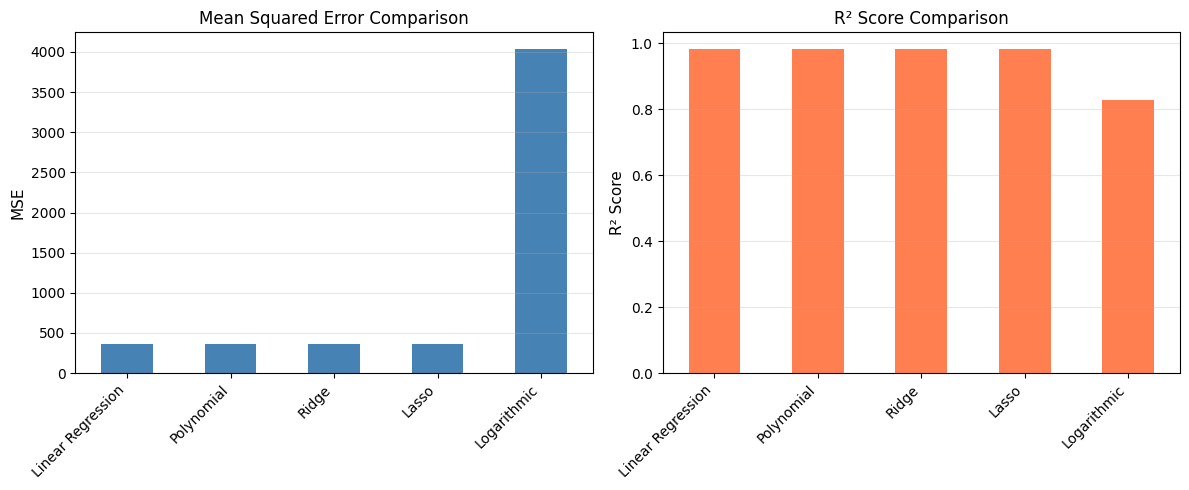

In [20]:
# BEGIN QUESTION
# name: regression_comparison_plot
# points: 0.5

# Create a comparison plot for regression models
# Store figure in: regression_comparison_plot

regression_comparison_plot = plt.figure(figsize=(12, 5))

# Subplot 1: MSE Comparison
plt.subplot(1, 2, 1)
regression_final_results['MSE'].plot(kind='bar', color='steelblue')
plt.title('Mean Squared Error Comparison', fontsize=12)
plt.ylabel('MSE', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')

# Subplot 2: R² Score Comparison
plt.subplot(1, 2, 2)
regression_final_results['R² Score'].plot(kind='bar', color='coral')
plt.title('R² Score Comparison', fontsize=12)
plt.ylabel('R² Score', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()

# END QUESTION

In [21]:
# BEGIN TESTS
assert regression_comparison_plot is not None
# END TESTS

---

## Summary

You have completed the assignment covering:

### Part A: Classification (5 marks)
- Trained 5 classification models on unbalanced data
- Tuned hyperparameters for all 5 models
- Evaluated and compared using Accuracy and ROC-AUC

### Part B: Regression (5 marks)
- Trained 5 regression models
- Tuned hyperparameters for all 5 models
- Evaluated and compared using MSE and R² Score

**Total Marks: 10 / 10**